# Multiclass Logistic Regression (Softmax Regression) with SGD

## What problem are we solving?
We want to predict a LendingClub **credit risk grade**:

- Grades: {A, B, C, D, E, F, G}  
- Mapped labels: `grade_idx` ∈ {0, 1, 2, 3, 4, 5, 6}

This is a **multiclass classification** problem with **7 classes**.

## What is Logistic Regression in the multiclass case?
For each example, the model computes **class scores**:

$$
s = Wx + b \quad \text{where } W \in \mathbb{R}^{d \times K},\; b \in \mathbb{R}^{K},\; K = 7
$$

Then we convert scores to probabilities using **softmax**:

$$
p(y = k \mid x) = \frac{e^{s_k}}{\sum_{j=1}^{K} e^{s_j}}
$$

We train the model by minimizing **cross-entropy loss**:

$$
\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N} \log p(y_i \mid x_i)
$$

## How do we train it?
We use **Stochastic Gradient Descent (SGD)**:
- Shuffle data each epoch
- Use mini-batches
- Compute gradients of cross-entropy
- Update parameters $W, b$

## Data pipeline
Because we have **categorical** + **numeric** features:
- Categorical -> **one-hot encoding**
- Numeric -> **standardization** (mean/std computed on TRAIN only)

### Diagram (data flow)
`X` (features) -> linear scores `(W, b)` -> softmax probabilities -> predicted class


Mount Drive + Imports + Paths

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Paths
DATA_ROOT = Path("/content/drive/MyDrive/ML Project/Data")
TRAIN_DIR = DATA_ROOT / "Train"
TEST_DIR  = DATA_ROOT / "Test"

train_csv = TRAIN_DIR / "train.csv"
dev_csv   = TRAIN_DIR / "dev.csv"
test_csv  = TEST_DIR  / "test.csv"

print("DATA_ROOT exists:", DATA_ROOT.exists())
print("TRAIN_DIR exists:", TRAIN_DIR.exists())
print("TEST_DIR exists:", TEST_DIR.exists())

print("Train CSV exists:", train_csv.exists(), train_csv)
print("Dev CSV exists:", dev_csv.exists(), dev_csv)
print("Test CSV exists:", test_csv.exists(), test_csv)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATA_ROOT exists: True
TRAIN_DIR exists: True
TEST_DIR exists: True
Train CSV exists: True /content/drive/MyDrive/ML Project/Data/Train/train.csv
Dev CSV exists: True /content/drive/MyDrive/ML Project/Data/Train/dev.csv
Test CSV exists: True /content/drive/MyDrive/ML Project/Data/Test/test.csv


## Load train / dev / test data

We read the CSV files from Google Drive and do basic sanity checks:
- shape
- column names
- class distribution (grade_idx)


In [ ]:
train_df = pd.read_csv(train_csv)
dev_df   = pd.read_csv(dev_csv)
test_df  = pd.read_csv(test_csv)

print("Train shape:", train_df.shape)
print("Dev shape:", dev_df.shape)
print("Test shape:", test_df.shape)

print("\nColumns:", list(train_df.columns))

# Basic check: target column exists
assert "grade_idx" in train_df.columns, "Expected 'grade_idx' in train.csv"
assert "grade_idx" in dev_df.columns, "Expected 'grade_idx' in dev.csv"
assert "grade_idx" in test_df.columns, "Expected 'grade_idx' in test.csv"

# Class distribution
print("\nTrain grade_idx counts:\n", train_df["grade_idx"].value_counts().sort_index())
print("\nDev grade_idx counts:\n", dev_df["grade_idx"].value_counts().sort_index())
print("\nTest grade_idx counts:\n", test_df["grade_idx"].value_counts().sort_index())

train_df.head()


Train shape: (59619, 24)
Dev shape: (12775, 24)
Test shape: (12782, 24)

Columns: ['grade', 'grade_idx', 'purpose', 'home_ownership', 'verification_status', 'addr_state', 'loan_amnt', 'term', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'total_acc', 'pub_rec', 'revol_bal', 'revol_util', 'collections_12_mths_ex_med', 'acc_now_delinq', 'pub_rec_bankruptcies', 'tax_liens', 'credit_history_months', 'fico_avg']

Train grade_idx counts:
 grade_idx
0    8517
1    8517
2    8517
3    8517
4    8517
5    8517
6    8517
Name: count, dtype: int64

Dev grade_idx counts:
 grade_idx
0    1825
1    1825
2    1825
3    1825
4    1825
5    1825
6    1825
Name: count, dtype: int64

Test grade_idx counts:
 grade_idx
0    1826
1    1826
2    1826
3    1826
4    1826
5    1826
6    1826
Name: count, dtype: int64


,grade,grade_idx,purpose,home_ownership,verification_status,addr_state,loan_amnt,term,emp_length,annual_inc,...,total_acc,pub_rec,revol_bal,revol_util,collections_12_mths_ex_med,acc_now_delinq,pub_rec_bankruptcies,tax_liens,credit_history_months,fico_avg
0,D,3,credit_card,RENT,Verified,CA,6000.0,36.0,10.0,65000.0,...,55.0,1.0,1363.0,3.6,0.0,0.0,1.0,0.0,218.020534,677.0
1,G,6,small_business,MORTGAGE,Source Verified,OH,14600.0,36.0,3.0,60000.0,...,11.0,0.0,6995.0,88.5,0.0,0.0,0.0,0.0,259.055441,667.0
2,G,6,debt_consolidation,MORTGAGE,Source Verified,CA,35000.0,36.0,10.0,184000.0,...,22.0,1.0,37361.0,62.7,0.0,0.0,0.0,1.0,128.985626,682.0
3,E,4,debt_consolidation,RENT,Source Verified,IL,15000.0,60.0,2.0,30000.0,...,38.0,0.0,13211.0,63.5,0.0,0.0,0.0,0.0,132.008214,672.0
4,E,4,debt_consolidation,RENT,Verified,MD,15200.0,60.0,4.0,38000.0,...,10.0,0.0,5600.0,70.0,0.0,0.0,0.0,0.0,223.934292,697.0


## Log-transform highly skewed numeric features

Some financial variables are **heavy-tailed** (they can have very large outliers).
We apply **log1p**:

$$
\mathrm{log1p}(x) = \log(1 + x)
$$

This compresses large values and usually makes SGD training more stable.


In [ ]:

skewness = train_df[NUM_COLS].skew(numeric_only=True).sort_values(ascending=False)

print("Top skewed numeric columns:")
print(skewness.head(10))

AUTO_SKEWED = skewness[skewness > 1.5].index.tolist()
print("\nApplying log1p to:", AUTO_SKEWED)

for c in AUTO_SKEWED:
    if (train_df[c] < 0).any():
        print(f"Skipping {c} (has negatives).")
        continue
    train_df[c] = np.log1p(train_df[c])
    dev_df[c]   = np.log1p(dev_df[c])
    test_df[c]  = np.log1p(test_df[c])


Top skewed numeric columns:
annual_inc                    66.795014
revol_bal                     32.014061
dti                           26.904044
acc_now_delinq                16.792364
tax_liens                     12.698437
collections_12_mths_ex_med     9.713799
delinq_2yrs                    5.597205
pub_rec                        5.243590
pub_rec_bankruptcies           3.580245
inq_last_6mths                 1.970620
dtype: float64

Applying log1p to: ['annual_inc', 'revol_bal', 'dti', 'acc_now_delinq', 'tax_liens', 'collections_12_mths_ex_med', 'delinq_2yrs', 'pub_rec', 'pub_rec_bankruptcies', 'inq_last_6mths']


## Define feature columns

We have:
- Categorical features: purpose, home_ownership, verification_status, addr_state
- Numeric features: everything else (except labels)



In [ ]:
TARGET_COL = "grade_idx"
DROP_COLS = ["grade"] if "grade" in train_df.columns else []  # optional string label

CAT_COLS = ["purpose", "home_ownership", "verification_status", "addr_state"]

# numeric columns = everything except target + dropped + categoricals
feature_cols = [c for c in train_df.columns if c not in ([TARGET_COL] + DROP_COLS)]
NUM_COLS = [c for c in feature_cols if c not in CAT_COLS]

print("Categorical features:", CAT_COLS)
print("Number of numeric features:", len(NUM_COLS))
print("Total feature columns (pre-encoding):", len(feature_cols))


Categorical features: ['purpose', 'home_ownership', 'verification_status', 'addr_state']
Number of numeric features: 18
Total feature columns (pre-encoding): 22


## One-hot encoding categorical features (TRAIN-fitted)

Important: we must avoid leaking test/dev category information into training.

Plan:
1. Collect categories from TRAIN for each categorical feature.
2. Replace unseen categories in dev/test with "UNK".
3. One-hot encode using those TRAIN categories (+ UNK).
4. Align columns so train/dev/test have the same feature dimensions.


In [ ]:
# Build train category vocab (train only)
cat_vocab = {}
for c in CAT_COLS:
    cats = sorted(train_df[c].unique().tolist())
    if "UNK" not in cats:
        cats.append("UNK")
    cat_vocab[c] = cats

def one_hot_encode(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    parts = []

    # numeric part stays numeric (we'll standardize later)
    parts.append(df[NUM_COLS].copy())

    # categorical -> controlled categories -> get_dummies
    for c in CAT_COLS:
        cats = cat_vocab[c]
        df[c] = df[c].where(df[c].isin(cats), "UNK")
        df[c] = pd.Categorical(df[c], categories=cats)
        d = pd.get_dummies(df[c], prefix=c)
        parts.append(d)

    X = pd.concat(parts, axis=1)
    return X

X_train_df = one_hot_encode(train_df)
X_dev_df   = one_hot_encode(dev_df)
X_test_df  = one_hot_encode(test_df)

print("Encoded shapes:")
print("X_train:", X_train_df.shape)
print("X_dev  :", X_dev_df.shape)
print("X_test :", X_test_df.shape)

# Ensure aligned columns
assert list(X_train_df.columns) == list(X_dev_df.columns) == list(X_test_df.columns)


Encoded shapes:
X_train: (59619, 95)
X_dev  : (12775, 95)
X_test : (12782, 95)


## Standardize numeric features (TRAIN mean/std only)

Logistic regression trains better when numeric inputs are on similar scales.

We standardize numeric columns using:

$$
x' = \frac{x - \mu}{\sigma}
$$

Here, $\mu$ and $\sigma$ are computed on **TRAIN only**, then reused for dev/test.


In [ ]:
# Identify which columns in the encoded matrix correspond to original numeric columns
encoded_num_cols = NUM_COLS  # these names remain as-is in X_train_df

train_mean = X_train_df[encoded_num_cols].mean()
train_std  = X_train_df[encoded_num_cols].std().replace(0, 1.0)

def standardize_encoded(Xdf: pd.DataFrame) -> pd.DataFrame:
    Xdf = Xdf.copy()
    Xdf[encoded_num_cols] = (Xdf[encoded_num_cols] - train_mean) / train_std
    return Xdf

X_train_df = standardize_encoded(X_train_df)
X_dev_df   = standardize_encoded(X_dev_df)
X_test_df  = standardize_encoded(X_test_df)

# Convert to numpy
X_train = X_train_df.to_numpy(dtype=np.float32)
X_dev   = X_dev_df.to_numpy(dtype=np.float32)
X_test  = X_test_df.to_numpy(dtype=np.float32)

y_train = train_df[TARGET_COL].to_numpy(dtype=np.int64)
y_dev   = dev_df[TARGET_COL].to_numpy(dtype=np.int64)
y_test  = test_df[TARGET_COL].to_numpy(dtype=np.int64)

print("Final numpy shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_dev  :", X_dev.shape,   "y_dev  :", y_dev.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)


Final numpy shapes:
X_train: (59619, 95) y_train: (59619,)
X_dev  : (12775, 95) y_dev  : (12775,)
X_test : (12782, 95) y_test : (12782,)


## Implement Softmax + Cross-Entropy

We will implement:
- stable softmax
- cross-entropy loss
- accuracy
- batched evaluation (so it runs fast on large datasets)


In [ ]:
def softmax(logits):
    # logits: (B, K)
    z = logits - np.max(logits, axis=1, keepdims=True)
    expz = np.exp(z)
    return expz / np.sum(expz, axis=1, keepdims=True)

def cross_entropy_loss(probs, y):
    # probs: (B, K), y: (B,)
    eps = 1e-12
    return float(-np.mean(np.log(probs[np.arange(len(y)), y] + eps)))

def predict(X, W, b):
    logits = X @ W + b
    return np.argmax(logits, axis=1)

def accuracy(y_pred, y_true):
    return float(np.mean(y_pred == y_true))

def eval_loss_and_acc(X, y, W, b, batch_size = 2048):
    n = X.shape[0]
    total_loss = 0.0
    total_correct = 0

    for i in range(0, n, batch_size):
        xb = X[i:i+batch_size]
        yb = y[i:i+batch_size]
        probs = softmax(xb @ W + b)
        total_loss += cross_entropy_loss(probs, yb) * len(yb)
        total_correct += np.sum(np.argmax(probs, axis=1) == yb)

    return total_loss / n, total_correct / n


## Train Multiclass Logistic Regression using SGD

We train the parameters:
- $W \in \mathbb{R}^{d \times 7}$
- $b \in \mathbb{R}^{7}$

**SGD loop:**
1. Shuffle training indices each epoch
2. Process mini-batches
3. Compute gradients
4. Update $W$ and $b$

We record:
- Train loss / dev loss per epoch
- Train accuracy / dev accuracy per epoch


In [ ]:
np.random.seed(42)
K = 7
d = X_train.shape[1]

# Training setup
epochs = 120
batch_size = 256
l2_reg = 1e-4

# Learning rate decay
lr0 = 0.1       # starting learning rate
decay = 0.97    # multiply lr by this each epoch

# Initialize parameters
W = 0.01 * np.random.randn(d, K).astype(np.float32)
b = np.zeros((K,), dtype=np.float32)

history = {"train_loss": [], "dev_loss": [], "train_acc": [], "dev_acc": []}
n = X_train.shape[0]

for epoch in range(1, epochs + 1):
    lr = lr0 * (decay ** (epoch - 1))  # decayed lr for this epoch

    # Shuffle
    idx = np.random.permutation(n)

    # Mini-batch SGD
    for start in range(0, n, batch_size):
        batch_idx = idx[start:start+batch_size]
        xb = X_train[batch_idx]  # (B, d)
        yb = y_train[batch_idx]  # (B,)

        # Forward
        logits = xb @ W + b
        probs = softmax(logits)

        # Gradient dL/dlogits
        B = xb.shape[0]
        grad_logits = probs.copy()
        grad_logits[np.arange(B), yb] -= 1.0
        grad_logits /= B

        # Gradients
        grad_W = xb.T @ grad_logits
        grad_b = np.sum(grad_logits, axis=0)

        # L2 regularization (optional)
        if l2_reg > 0:
            grad_W += l2_reg * W

        # Update
        W -= lr * grad_W.astype(np.float32)
        b -= lr * grad_b.astype(np.float32)

    # End of epoch: evaluate
    tr_loss, tr_acc = eval_loss_and_acc(X_train, y_train, W, b)
    dv_loss, dv_acc = eval_loss_and_acc(X_dev, y_dev, W, b)

    history["train_loss"].append(tr_loss)
    history["dev_loss"].append(dv_loss)
    history["train_acc"].append(tr_acc)
    history["dev_acc"].append(dv_acc)

    if epoch == 1 or epoch % 10 == 0:
        print(f"Epoch {epoch:03d}/{epochs} | lr={lr:.5f} | "
              f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
              f"dev loss={dv_loss:.4f}, acc={dv_acc:.4f}")


Epoch 001/120 | lr=0.10000 | train loss=1.5525, acc=0.3457 | dev loss=1.5555, acc=0.3396
Epoch 010/120 | lr=0.07602 | train loss=1.4934, acc=0.3658 | dev loss=1.4964, acc=0.3562
Epoch 020/120 | lr=0.05606 | train loss=1.4884, acc=0.3680 | dev loss=1.4913, acc=0.3584
Epoch 030/120 | lr=0.04134 | train loss=1.4868, acc=0.3676 | dev loss=1.4899, acc=0.3605
Epoch 040/120 | lr=0.03049 | train loss=1.4860, acc=0.3691 | dev loss=1.4894, acc=0.3602
Epoch 050/120 | lr=0.02248 | train loss=1.4856, acc=0.3685 | dev loss=1.4891, acc=0.3613
Epoch 060/120 | lr=0.01658 | train loss=1.4853, acc=0.3684 | dev loss=1.4887, acc=0.3620
Epoch 070/120 | lr=0.01223 | train loss=1.4851, acc=0.3688 | dev loss=1.4886, acc=0.3616
Epoch 080/120 | lr=0.00902 | train loss=1.4850, acc=0.3685 | dev loss=1.4886, acc=0.3625
Epoch 090/120 | lr=0.00665 | train loss=1.4849, acc=0.3688 | dev loss=1.4885, acc=0.3622
Epoch 100/120 | lr=0.00490 | train loss=1.4849, acc=0.3688 | dev loss=1.4885, acc=0.3619
Epoch 110/120 | lr=0.

## Plot Cross-Entropy loss curves (Train vs Dev)

The assignment asks for cross-entropy loss plotted over training epochs.


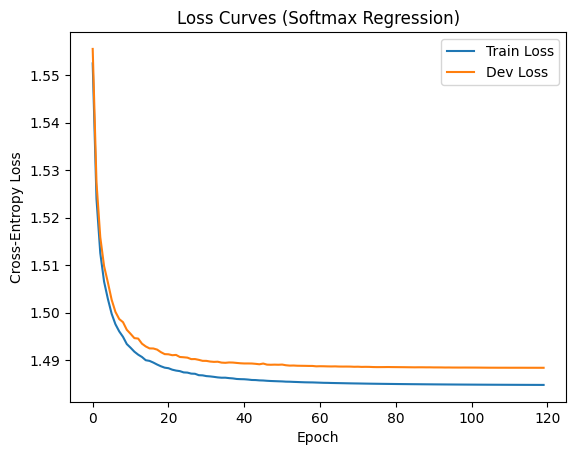

In [ ]:
plt.figure()
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["dev_loss"], label="Dev Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Loss Curves (Softmax Regression)")
plt.legend()
plt.show()


## Plot Accuracy curves (Train vs Dev)

This helps diagnose overfitting/underfitting:
- Train goes up but Dev goes down -> overfitting
- Both low -> underfitting / learning rate issue


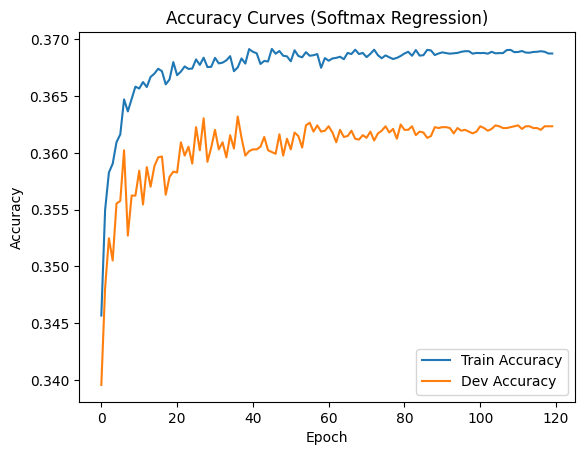

In [ ]:
plt.figure()
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["dev_acc"], label="Dev Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curves (Softmax Regression)")
plt.legend()
plt.show()


## Final evaluation (Train / Dev / Test)

Now we compute the final accuracy and loss on:
- training set
- development set
- test set


In [ ]:
train_loss, train_acc = eval_loss_and_acc(X_train, y_train, W, b)
dev_loss, dev_acc     = eval_loss_and_acc(X_dev, y_dev, W, b)
test_loss, test_acc   = eval_loss_and_acc(X_test, y_test, W, b)

print("Final Results:")
print(f"Train | loss={train_loss:.4f}, acc={train_acc:.4f}")
print(f"Dev   | loss={dev_loss:.4f}, acc={dev_acc:.4f}")
print(f"Test  | loss={test_loss:.4f}, acc={test_acc:.4f}")


Final Results:
Train | loss=1.4848, acc=0.3688
Dev   | loss=1.4884, acc=0.3623
Test  | loss=1.4927, acc=0.3577


##  Confusion Matrix
A confusion matrix shows *which grades are confused with which others*.



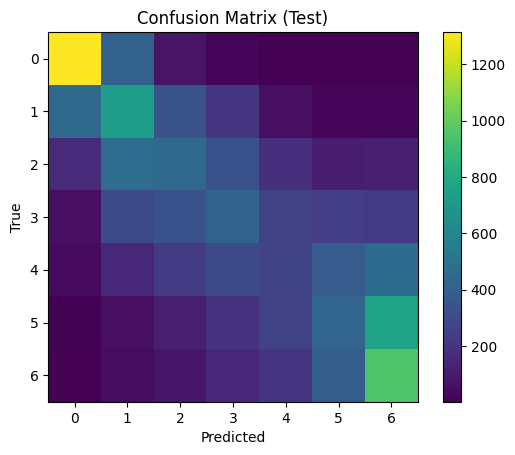

Confusion Matrix:
 [[1314  408   69   25    5    3    2]
 [ 456  731  340  198   55   25   21]
 [ 157  473  455  333  181  109  118]
 [  57  296  332  418  260  239  224]
 [  39  148  233  289  271  380  466]
 [  11   56  116  189  261  428  765]
 [   4   45   82  151  200  389  955]]


In [ ]:
def confusion_matrix(y_true, y_pred, num_classes=7):
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

y_test_pred = predict(X_test, W, b)
cm = confusion_matrix(y_test, y_test_pred, num_classes=7)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()

print("Confusion Matrix:\n", cm)


## Per-class Precision / Recall / F1 (from confusion matrix)

We compute class-wise metrics directly from the confusion matrix.
This helps explain which grades are easier/harder to predict.


In [ ]:
cm = np.array(cm)  # if yours is already a numpy array, this line is harmless
labels = list("ABCDEFG")

row_sum = cm.sum(axis=1)
col_sum = cm.sum(axis=0)

precision = np.diag(cm) / np.maximum(col_sum, 1)
recall    = np.diag(cm) / np.maximum(row_sum, 1)
f1        = 2 * precision * recall / np.maximum(precision + recall, 1e-12)

print("Per-class metrics:")
for i, lab in enumerate(labels):
    print(f"{lab}: precision={precision[i]:.3f}, recall={recall[i]:.3f}, f1={f1[i]:.3f}")

print("\nMacro averages:")
print(f"Macro precision={precision.mean():.3f}")
print(f"Macro recall   ={recall.mean():.3f}")
print(f"Macro F1       ={f1.mean():.3f}")

# Correct or off-by-1 (ordinal closeness)
within1 = 0
for i in range(7):
    for j in range(7):
        if abs(i-j) <= 1:
            within1 += cm[i, j]
print(f"\nCorrect or off-by-1 grade: {within1/cm.sum():.3f}")


Per-class metrics:
A: precision=0.645, recall=0.720, f1=0.680
B: precision=0.339, recall=0.400, f1=0.367
C: precision=0.280, recall=0.249, f1=0.264
D: precision=0.261, recall=0.229, f1=0.244
E: precision=0.220, recall=0.148, f1=0.177
F: precision=0.272, recall=0.234, f1=0.252
G: precision=0.374, recall=0.523, f1=0.436

Macro averages:
Macro precision=0.341
Macro recall   =0.358
Macro F1       =0.346

Correct or off-by-1 grade: 0.724


## Visualize per class performance

On the test set, per-class metrics show a clear **U shape**: the model is strongest on the extremes and weakest in the middle.

- **Best:** **A** (Recall ≈ 0.72, F1 ≈ 0.68) and **G** (Recall ≈ 0.52, F1 ≈ 0.44)
- **Harder:** **B** is moderate (Recall/F1 ≈ 0.40/0.37)
- **Weak:** **C–F** are low overall (Recall/F1 ≈ 0.20–0.26)
- **Worst:** **E** (Recall ≈ 0.15, F1 ≈ 0.18)

Recall is usually a bit higher than F1, meaning the model often **catches** the class but with **extra false positives** (lower precision), especially for **G**.  
This pattern suggests confusion mainly between **neighboring grades** (e.g., C vs D vs E).


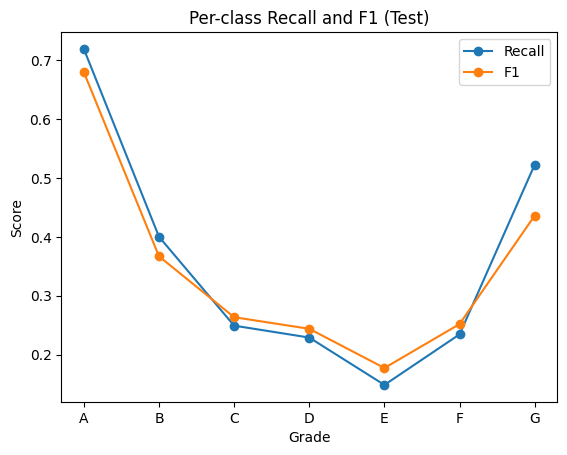

In [ ]:
labels = list("ABCDEFG")

plt.figure()
plt.plot(labels, recall, marker="o", label="Recall")
plt.plot(labels, f1, marker="o", label="F1")
plt.xlabel("Grade")
plt.ylabel("Score")
plt.title("Per-class Recall and F1 (Test)")
plt.legend()
plt.show()
